# Brändimielikuvan kartoitus korrespondenssianalyysillä (PROC CORRESP)

## Tiivistelmä

Markkinatutkimustiimi toteuttaa brändi-attribuutti-mielikuvakyselyn neljälle vakiintuneelle suoratoistomediabrändille ja käyttää **PROC CORRESP** -proseduuria muuntaakseen tuloksena syntyvän ristiintaulukon kaksiulotteiseksi mielikuvakartaksi. Brändi x attribuutti -yhteys on vahva ja todellinen: riippumattomuuden khiin neliö -testi on **63,15, 15 vapausastetta (p < 0,0001)**, ja **Cramérin V = 0,4588**. Korrespondenssianalyysi tiivistää tuon yhteyden kahteen akseliin, jotka yhdessä selittävät **100 %** taulukon inertiasta — **75,0 %** ulottuvuudella 1 ja **25,0 %** ulottuvuudella 2 — joten 2-ulotteinen kartta on täydellinen, uskollinen yhteenveto.

Kartta erottaa **premium-sisältö**-navan (CineNow, ankkuroituna *Original_Shows*- ja *Content_Depth*-attribuutteihin) **arvo/luotettavuus**-ryhmästä (Streamly ja BingeBox lähellä *Affordable*- ja *Reliable*-attribuutteja) ja **trendikkäästä** kulmasta (PixelPlay lähellä *Trendy*-attribuuttia). Nouseva haastaja, **NovaCast**, projisoidaan sitten *täydentävänä* pisteenä — se ei vaikuta akseleihin — ja asettuu lähelle origoa, nojaten hieman Trendy / Easy_to_Use -puolelle, eli vielä erilaistumaton tulokas.

## Tietolähteet

| Aineisto | Rivit | Avainmuuttujat | Kuvaus |
|---------|------|---------------|-------------|
| `perception` | 100 (vastaaja x attribuutti -yhteyksiä, lisensoimattoman tilan raja) | `Brand` (char), `Attribute` (char) | Synteettinen kysely: kukin vastaaja nimeää suoratoistobrändin, jonka hän eniten yhdistää kuhunkin kuudesta attribuutista. Brändiaffiniteetit koodataan `RAND("Table", ...)` -kategoriatodennäköisyyksinä, joten kontingenssitaulukolla on realistinen, ei-tasainen yhteysrakenne. |
| `survey_counts` | 24 (4 brändiä x 6 attribuuttia) | `Brand`, `Attribute`, `Count` | Ennalta aggregoidut kontingenssisolut aineistosta `perception` PROC FREQ:in kautta — painotettu syöte täydentävän pisteen CA-ajoon. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | `OUTC=`-koordinaattiaineistot, jotka PROC CORRESP kirjoittaa; jälkimmäinen lisää projisoidun NovaCast-pisteen ja ohjaa mielikuvakarttaa. |

Vakiintuneet brändit: **Streamly, PixelPlay, CineNow, BingeBox**; haastaja **NovaCast** (projisoituna täydentävänä pisteenä). Attribuutit: Affordable, Content_Depth, Easy_to_Use, Original_Shows, Reliable, Trendy. Siemenluku `streaminit(20260531)` tekee datasta toistettavan.

> **Huomautus otoskoosta.** Tämä ympäristö toimii lisensoimattomana, joten DATA-askeleen tuloste rajataan 100 havaintoon. Kysely ratkeaa siksi 4x6-kontingenssitauluksi, jonka kokonaissumma on 100 vastaaja-attribuutti-yhteyttä — pieni, mutta jolla on aitoa yhteysrakennetta (khiin neliö p < 0,0001), jonka korrespondenssianalyysi palauttaa siististi.

## Mitä korrespondenssianalyysi tekee tässä

Kun brändinseurantakysely kysyy kuluttajilta, minkä brändin he eniten yhdistävät kuhunkin useasta attribuutista, tuloksena on **brändi x attribuutti -kontingenssitaulukko**. Raakalukumäärät ovat vaikeasti luettavia: jokaista brändiä verrataan jokaiseen attribuuttiin, ja signaali on *yhteyden kuvio*, ei solujen arvot.

Korrespondenssianalyysi (CA) hajottaa taulukon khiin neliö -yhteyden matalaulotteiseen avaruuteen, joten toisiinsa yhteydessä olevat brändit ja attribuutit asettuvat lähelle toisiaan samalla kartalla. Tässä muistikirjassa me:

1. Generoimme synteettisen mielikuvakyselyn neljälle suoratoistobrändille.
2. Tarkastelemme raakaa kontingenssirakennetta (ja sen khiin neliötä) `PROC FREQ` -proseduurilla.
3. Ajamme `PROC CORRESP` -proseduurin täysin diagnostiikoin ja luemme todellisen inertian ja koordinaatit.
4. Projisoimme nousevan haastajabrändin **täydentävänä** pisteenä.
5. Piirrämme ja tulkitsemme tuloksena syntyvän mielikuvakartan.

## Vaihe 1 — Generoi synteettinen mielikuvakysely

Simuloimme kyselyn vastaajia. Kultakin vastaajalta kysymme kunkin kuuden attribuutin osalta, *minkä brändin yhdistät eniten tähän attribuuttiin?* Kullakin brändillä on erillinen **affiniteettiprofiili** — kategoriatodennäköisyyksien vektori, joka välitetään `RAND("Table", ...)` -funktiolle — niin että esimerkiksi *PixelPlay* painottuu Trendy-suuntaan, kun taas *CineNow* painottuu Content_Depth- ja Original_Shows-suuntaan. Tämä tuottaa kontingenssitaulukon, jolla on aitoa, ei-tasaista yhteyttä CA:n palautettavaksi. Data on täysin synteettistä ja toistettavaa `CALL STREAMINIT` -komennon kautta.

In [1]:
TIEDOT perception;
    /* Toistettava synteettinen brändimielikuvakysely */
    CALL streaminit(20260531);

    PITUUS Brand $9 Attribute $14;
    TAULUKKO attrname[6] $14 _temporary_
        ('Affordable' 'Content_Depth' 'Easy_to_Use'
         'Original_Shows' 'Reliable' 'Trendy');

    n_resp = 400;

    TEE respondent = 1 ASTI n_resp;
        TEE a = 1 ASTI 6;
            Attribute = attrname[a];

            /* Attribuuttikohtaiset brändinvalintatodennäköisyydet
               neljän vakiintuneen brändin yli:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Kukin rivi summautuu ~1:een ja koodaa attribuutin
               brändiaffiniteetin. */
            JOS      a = 1 NIIN b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Affordable    */
            MUUTEN JOS a = 2 NIIN b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Content_Depth */
            MUUTEN JOS a = 3 NIIN b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Easy_to_Use   */
            MUUTEN JOS a = 4 NIIN b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Original_Shows*/
            MUUTEN JOS a = 5 NIIN b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Reliable      */
            MUUTEN              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Trendy        */

            VALITSE (b);
                KUN (1) Brand = 'Streamly';
                KUN (2) Brand = 'PixelPlay';
                KUN (3) Brand = 'CineNow';
                MUULLOIN Brand = 'BingeBox';
            LOPPU;

            TULOSTE;
        LOPPU;
    LOPPU;

    SÄILYTÄ respondent Brand Attribute;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=perception(obs=8) noobs label;
    NIMIKE respondent="Vastaaja" Brand="Brändi" Attribute="Attribuutti";
    OTSIKKO 'Otos synteettisestä mielikuvakyselystä';
SUORITA;

                                         Otos synteettisestä mielikuvakyselystä                                         

Vastaaja     Brändi     Attribuutti
       1  BingeBox   Affordable
       1  BingeBox   Content_Depth
       1  BingeBox   Easy_to_Use
       1  CineNow    Original_Shows
       1  Streamly   Reliable
       1  PixelPlay  Trendy
       2  PixelPlay  Affordable
       2  CineNow    Content_Depth

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.31 seconds
  cpu   0.31 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Vaihe 2 — Tarkastele raakaa kontingenssitaulukkoa

Ennen mitään ulottuvuuden vähennystä katso ristiintaulukkoa. `PROC FREQ` antaa havaitut brändi x attribuutti -frekvenssit ja riippumattomuuden khiin neliö -testin. Merkitsevä khiin neliö vahvistaa, että on olemassa kartoittamisen arvoista yhteysrakennetta — jos rivit ja sarakkeet olisivat riippumattomia, korrespondenssianalyysillä ei olisi mitään näytettävää. Tallennamme myös soluluvut aineistoon `survey_counts` myöhempää täydentävän pisteen CA-ajoa varten.

                                       Havaitut brändi x attribuutti -frekvenssit                                       

                                                   The FREQ Procedure

Table of Brändi by Attribuutti

Brändi    |    Affordable | Content_Depth |   Easy_to_Use |Original_Shows |      Reliable |        Trendy |          Total
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
BingeBox  |             5 |             3 |             7 |             1 |             6 |             2 |             24
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
CineNow   |             3 |             9 |             0 |            14 |             2 |             0 |             28
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
PixelPlay |             3 |          


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


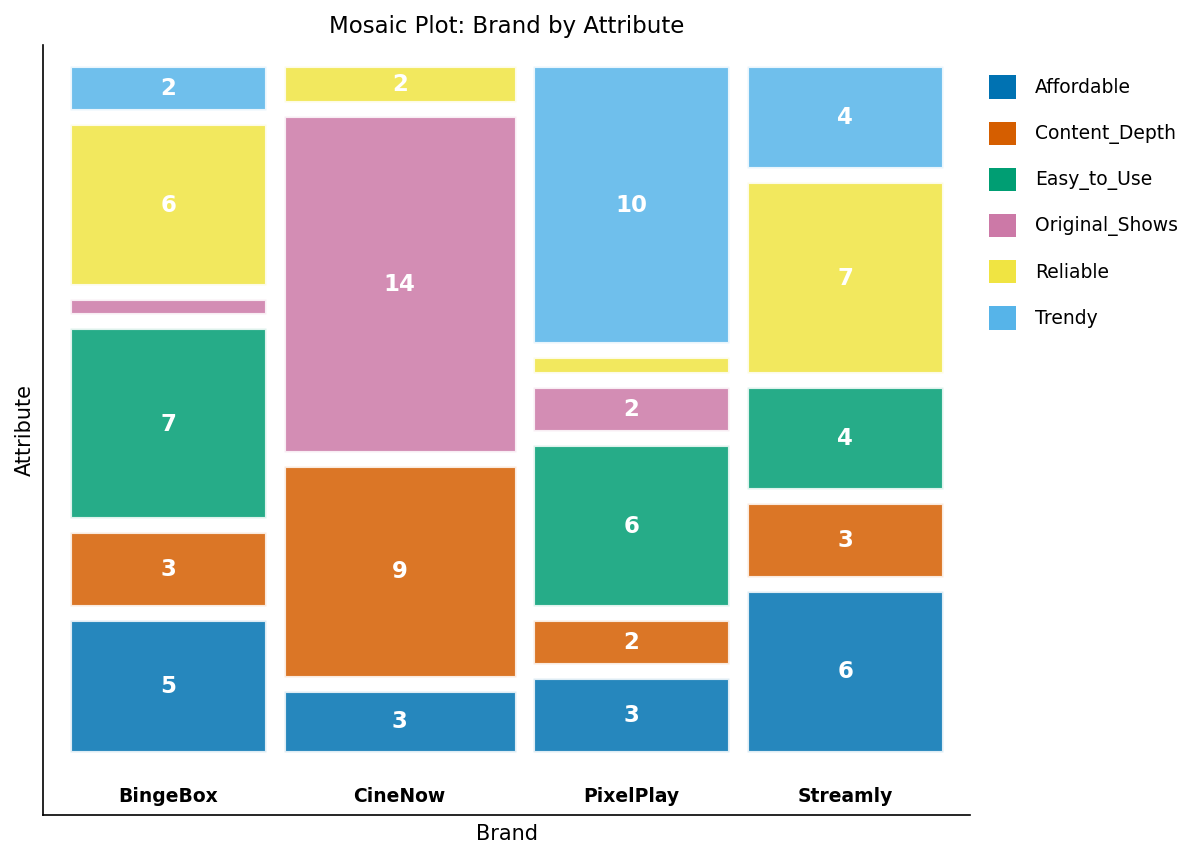

In [2]:
PROSEDUURI FREKVENSSIT TIEDOT=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(rename=(count=Count));
    NIMIKE Brand="Brändi" Attribute="Attribuutti";
    OTSIKKO 'Havaitut brändi x attribuutti -frekvenssit';
SUORITA;

## Vaihe 3 — Korrespondenssianalyysi raakadatasta

Aja nyt `PROC CORRESP` suoraan vastaajatason dataan. `TABLES Brand, Attribute;` rakentaa kontingenssitaulukon sisäisesti (brändit riveinä, attribuutit sarakkeina).

Tässä käytetyt optiot:

- `ALL` — tulosta täysi diagnostiikka: havaittu taulukko, profiilit, odotetut arvot ja   solujen khiin neliö -osuudet.
- `DIMENS=2` — laske kaksi ensimmäistä pääakselia (2-ulotteinen kartta).
- `OUTC=` — kirjoita rivi- ja sarakekoordinaatit aineistoon piirtämistä varten.

**Inertian hajotelma** kertoo, kuinka suuren osan kokonaisyhteydestä kukin akseli selittää.

In [3]:
PROSEDUURI corresp TIEDOT=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    NIMIKE Brand="Brändi" Attribute="Attribuutti";
    OTSIKKO 'Korrespondenssianalyysi: suoratoistobrändien mielikuva';
SUORITA;

                                       Havaitut brändi x attribuutti -frekvenssit                                       

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brändi                  Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Vaihe 4 — Lue koordinaatit

`OUTC=`-aineisto sisältää akselikoordinaatit (`Dim1`, `Dim2`) jokaiselle brändille ja attribuutille, merkittynä `_TYPE_`-muuttujalla (`ROW` brändeille, `COLUMN` attribuuteille). Niiden lukeminen numeerisesti inertiataulukon rinnalla vahvistaa rakenteen, jonka kartta tulee näyttämään.

Yllä olevasta tulosteesta:

- **Ulottuvuus 1 (75,0 % inertiasta)** on *premium-sisältö vs. valtavirta* -akseli.   *Original_Shows* (Dim1 = -1,2037) ja *Content_Depth* (-0,5594) sijaitsevat negatiivisessa   päässä **CineNown** (-1,0847) kanssa; *Trendy* (0,6671), *Easy_to_Use* (0,6150) ja   *Affordable* (0,2207) sijaitsevat positiivisessa päässä.
- **Ulottuvuus 2 (25,0 % inertiasta)** erottaa *Reliable*-attribuutin (Dim2 = 0,5874) ja   *Affordable*-attribuutin (0,2542) — vetäen ylös **Streamlyn** (0,3207) ja **BingeBoxin** (0,3555) —   *Trendy*-attribuutista (-0,7003), joka vetää alas **PixelPlayn** (-0,6374).

In [4]:
PROSEDUURI TULOSTA TIEDOT=ca_coords noobs label;
    MUUTTUJA _TYPE_ _NAME_ Dim1 Dim2;
    NIMIKE _TYPE_="Tyyppi" _NAME_="Nimi" Dim1="Ulottuvuus 1" Dim2="Ulottuvuus 2";
    OTSIKKO 'Rivi- (brändi) ja sarake- (attribuutti) koordinaatit';
SUORITA;

                                  Rivi- (brändi) ja sarake- (attribuutti) koordinaatit                                  

Tyyppi              Nimi  Ulottuvuus 1  Ulottuvuus 2
ROW     BingeBox                0.3547        0.3555
ROW     CineNow                -1.0847       -0.0332
ROW     PixelPlay               0.4804       -0.6374
ROW     Streamly                0.4304        0.3207
COLUMN  Affordable              0.2207        0.2542
COLUMN  Content_Depth          -0.5594        0.0684
COLUMN  Easy_to_Use             0.6150       -0.0080
COLUMN  Original_Shows         -1.2037       -0.2084
COLUMN  Reliable                0.3183        0.5874
COLUMN  Trendy                  0.6671       -0.7003




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Vaihe 5 — Projisoi haastajabrändi täydentävänä pisteenä

Analytiikkatiimillä on seurantadataa nousevasta haastajasta, **NovaCastista**, mutta se ei halua sen vääristävän vakiintunutta mielikuvakarttaa. *Täydentävä* piste projisoidaan olemassa olevaan CA-avaruuteen **osallistumatta akselien laskentaan**.

Liitämme yhden lohkon kuutta NovaCast-attribuuttilukua (Trendy / Original-Shows -painotteinen tulokas) ennalta aggregoituun aineistoon `survey_counts`, syötämme frekvenssit komennolla `WEIGHT Count`, ja nimeämme **tason** `NovaCast` `SUPPLEMENTARY`-lauseessa, jotta PROC CORRESP pitää tuon rivin aktiivisen taulukon ulkopuolella. `OBSERVED`-optio pitää aktiivisen kontingenssitaulukon (neljä vakiintunutta brändiä, summa 100) näkyvissä — huomaa, että NovaCast ei **esiinny** siinä, mikä vahvistaa, että sitä käsiteltiin täydentävänä.

In [5]:
/* Liitä YKSI siisti lohko NovaCast-lukuja aggregoituihin soluihin.
   end=last laukaisee lohkon täsmälleen kerran, viimeisen survey_counts-rivin
   jälkeen, joten NovaCast tuo kuusi riviä (yksi per attribuutti) -- ei
   monistettua lohkoa. NovaCast on Trendy / Original-Shows -painotteinen tulokas. */
TIEDOT survey_counts_sup;
    ASETA survey_counts end=last;
    TULOSTE;
    JOS last NIIN TEE;
        Brand='NovaCast'; Attribute='Trendy';          Count=10; TULOSTE;
        Brand='NovaCast'; Attribute='Original_Shows';  Count=8;  TULOSTE;
        Brand='NovaCast'; Attribute='Easy_to_Use';     Count=5;  TULOSTE;
        Brand='NovaCast'; Attribute='Content_Depth';   Count=3;  TULOSTE;
        Brand='NovaCast'; Attribute='Affordable';      Count=4;  TULOSTE;
        Brand='NovaCast'; Attribute='Reliable';        Count=3;  TULOSTE;
    LOPPU;
SUORITA;

PROSEDUURI corresp TIEDOT=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    PAINO Count;
    supplementary NovaCast;
    NIMIKE Brand="Brändi" Attribute="Attribuutti" Count="Lukumäärä";
    OTSIKKO 'Brändimielikuva NovaCast täydentävänä pisteenä';
SUORITA;

                                  Rivi- (brändi) ja sarake- (attribuutti) koordinaatit                                  

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brändi                  Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Vaihe 6 — Piirrä mielikuvakartta

PROC CORRESP kirjoittaa symmetriset rivi/sarake-koordinaatit `OUTC=`-aineistoon; piirrämme ulottuvuuden 2 ulottuvuutta 1 vasten renderöidäksemme kartan. Merkitsemme kunkin pisteen **roolin** mukaan — *Brand* (aktiiviset rivit), *Attribute* (sarakkeet) ja *Challenger* (täydentävä NovaCast-rivi) — ja nimeämme jokaisen merkin, joten sijainti luetaan suoraan kuvaajasta. Haastaja väritetään erikseen korostaakseen, että se projisoitiin sisään eikä sovitettu.

> **Kuinka CA-karttaa luetaan.** Brändi ja attribuutti, jotka sijaitsevat samassa suunnassa origosta (ja kaukana siitä), ovat vahvasti yhteydessä; origoa lähellä olevat pisteet ovat "keskimääräisiä" ja heikosti erilaistuneita. Koska ulottuvuudet 1 ja 2 kaappaavat yhdessä 100 % tämän taulukon inertiasta, kartta ei jätä mitään pois.

               Suoratoistobrändien mielikuvakartta (Ulottuvuus 1 75,0 %, Ulottuvuus 2 25,0 % inertiasta)                

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dim1, Dim2

      Role      _NAME_        Dim1        Dim2
----------  ----------  ----------  ----------
     Brand    BingeBox      0.3547      0.3555
     Brand     CineNow     -1.0847     -0.0332
     Brand   PixelPlay      0.4804     -0.6374
     Brand    Streamly      0.4304      0.3207
Challenger    NovaCast      0.0084     -0.1735
 Attribute  Affordable      0.2207      0.2542
 Attribute  Content_Depth     -0.5594      0.0684
 Attribute  Easy_to_Use       0.615      -0.008
 Attribute  Original_Shows     -1.2037     -0.2084
 Attribute    Reliable      0.3183      0.5874
 Attribute      Trendy      0.6671     -0.7003

Dim1: N=11, Min=-1.2037, Max=0.6671, Mean=0.0225, Sum=0.2472
Dim2: N=11, Min=-0.7003, Max=0.5874, Mean=-0.0159, Sum=-0.1746



NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Suoratoistobrändien mielikuvakartta (Ulottuvuus 1 75,0 %, Ulottuvuus 2 25,0 % inertiasta).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


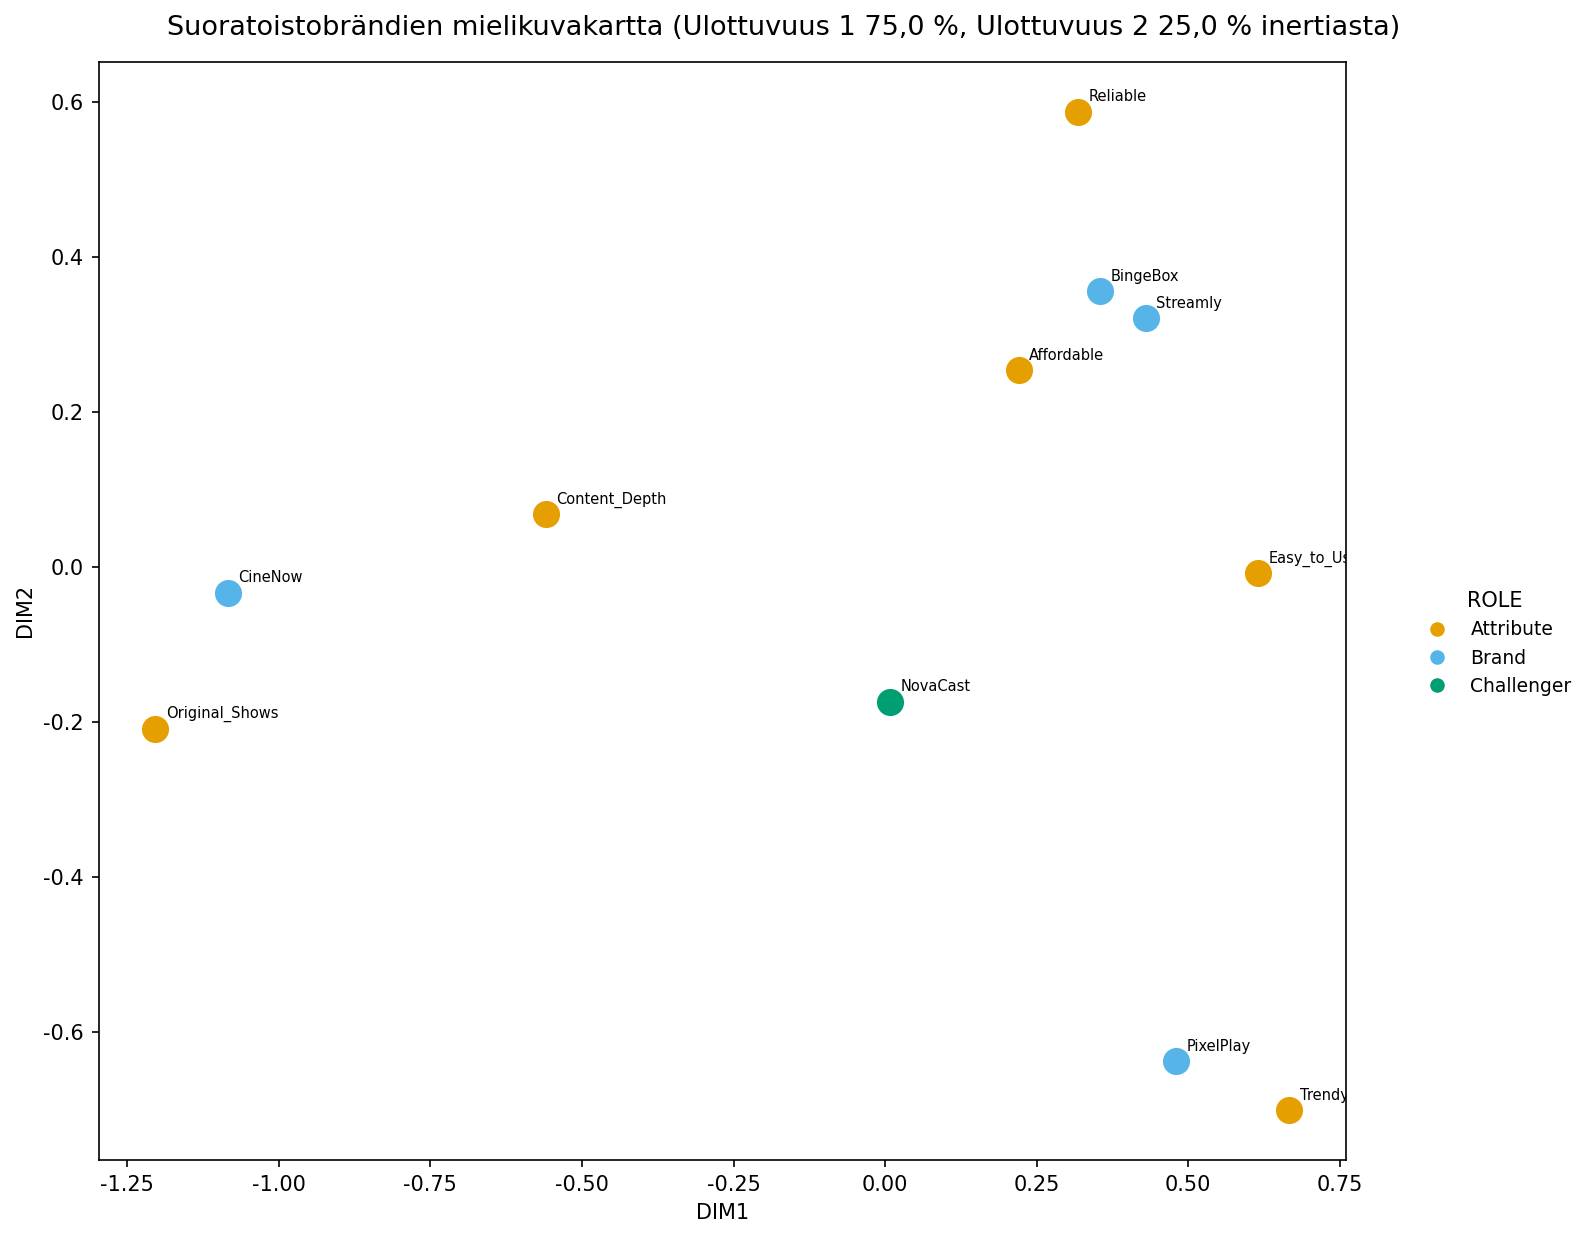

In [6]:
/* Merkitse kukin OUTC-piste roolinsa mukaan siistiä, väritettyä
   selitettä varten. Täydentävä NovaCast kirjoitetaan OUTC:hen arvolla
   _TYPE_='ROW', joten käsittelemme sen erikseen haastajana (Challenger). */
TIEDOT ca_map;
    ASETA ca_coords_sup;
    PITUUS Role $10;
    JOS _NAME_ = 'NovaCast' NIIN Role = 'Challenger';
    MUUTEN JOS _TYPE_ = 'ROW' NIIN Role = 'Brand';
    MUUTEN Role = 'Attribute';
    SÄILYTÄ Role _NAME_ Dim1 Dim2;
SUORITA;

/* Aseta kartan otsikko globaalisti ennen PROC:ia, jotta se otsikoi tämän
   kuvaajan (globaali TITLE ohjaa ODS-grafiikan otsikkoa). */
OTSIKKO 'Suoratoistobrändien mielikuvakartta (Ulottuvuus 1 75,0 %, Ulottuvuus 2 25,0 % inertiasta)';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* PROC CORRESP:lla ei ole natiivia ODS-karttaa tässä versiossa, joten
   renderöimme symmetriset koordinaatit PROC SGSCATTER:lla, joka nimeää kunkin pisteen. */
PROSEDUURI SGSCATTER TIEDOT=ca_map;
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
SUORITA;

ODS GRAPHICS OFF;
OTSIKKO;

## Tulosten tulkinta

**Yhteys on todellinen ja täysin kaapattu.** Khiin neliö -testi (63,15, 15 vapausastetta, p < 0,0001; Cramérin V = 0,4588) hylkää riippumattomuuden, ja kaksi CA-ulottuvuutta selittävät **100 %** taulukon inertiasta (75,0 % + 25,0 %), joten alla oleva kartta on täydellinen yhteenveto, ei häviöllinen projektio.

**Kolme mielikuvaterritoriota.** Koordinaatteja ja karttaa yhdessä lukien:

- **Premium-sisältö (vasen).** *CineNow* (Dim1 = -1,0847) vedetään kauas vasemmalle   *Original_Shows*- (-1,2037) ja *Content_Depth*- (-0,5594) attribuuttien toimesta — se omistaa   katalogin syvyyden mielikuvan.
- **Arvo & luotettavuus (oikea ylä).** *Streamly* (0,4304, 0,3207) ja *BingeBox*   (0,3547, 0,3555) ryhmittyvät *Affordable*- (0,2207, 0,2542) ja *Reliable*- (0,3183,   0,5874) attribuuttien kanssa — luotettava, hyvän hinta-laatusuhteen pari.
- **Trendikäs (oikea ala).** *PixelPlay* (0,4804, -0,6374) sijaitsee *Trendy*-attribuutin   (0,6671, -0,7003) vieressä — nuorekas, hetken brändi.

**Täydentävä haastaja.** Projisoituna akseleihin vaikuttamatta **NovaCast** asettuu pisteeseen (0,0084, -0,1735) — olennaisesti origoon, tönäistynä Trendy / Easy_to_Use -puolelle. Mediastrategille se on pääuutinen: haastajalla ei ole vielä erottuvaa pääomaa ja se ajautuu PixelPlayn trendikkääseen territorioon, joten erilaistettu asemointi (jäljittelevän sijaan) on perusteltu.

**Varaumat.** Korrespondenssianalyysi on kuvailevaa, ei päättelevää — etäisyydet ovat likimääräisiä ja akselien *merkit* mielivaltaisia (kummankin akselin peilikäännös on sama kartta). Vain 100 vastaaja-attribuutti-yhteydellä kaksi solua on nollaa (CineNow x Easy_to_Use, Streamly x Original_Shows), mikä terävöittää ääripäitä; tuotantotutkimus toteuttaisi suuremman otoksen. Yhdistä kartta aina inertiataulukkoon vahvistaaksesi, kuinka paljon yhteyttä näytetyt ulottuvuudet selittävät.